# MATH 6241 — Project 1 (Full Analysis Notebook)
## Time Series Modeling Using a Markov Chain
### Dataset: AirQualityUCI

This notebook performs a **complete end-to-end analysis** for Project 1 using:

- **Dataset:** `AirQualityUCI.csv`
- A single time series variable (we will use **CO(GT)** by default)

It follows the project steps:

1. Load + clean a real time series dataset  
2. Discretize into a finite state space to obtain a Markov chain  
3. Estimate empirical distribution and transition matrix  
4. Compute stationary distribution  
5. Compare empirical vs stationary distributions  
6. Simulate the fitted Markov chain and compare time series behavior  
7. Perform a **2-step transition goodness-of-fit test** (chi-square with pooling when needed)

> You can change the chosen variable (e.g., `PT08.S1(CO)`, `NO2(GT)`, etc.) by editing one cell below.


## 0. Setup

### Install / imports
You may use **Python** (recommended), MATLAB, or R. This notebook uses Python.

**Allowed libraries:** `numpy`, `pandas`, `matplotlib`, `scipy` (optional), `statsmodels` (optional).  
If you do not have SciPy, you can still compute p-values via chi-square critical values or implement simple functions.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional for chi-square test p-values / critical values
try:
    from scipy.stats import chi2
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False
    chi2 = None

np.random.seed(0)
print("SciPy available:", SCIPY_AVAILABLE)


SciPy available: True


## 1. Load the dataset (Step 1)

### Requirements
- Publicly available dataset (e.g., UCI Time Series)
- A **single numeric time series variable**
- Preferably **≥ 1000** observations
- Include a citation/link in your report

### TODO
1. Download your dataset and place it in the same folder as this notebook, or provide a URL and download it.
2. Load it into a pandas DataFrame.
3. Select one column as your numeric time series.

> If your dataset is already a CSV with a single numeric column, your job is easy.


The UCI Air Quality dataset is commonly stored as a semicolon-separated CSV with **decimal commas**.
We load it robustly and inspect the columns.

**File provided:** `AirQualityUCI.csv`


In [ ]:
DATA_PATH = "sample_data/AirQualityUCI.csv"  # put the file in the same folder as this notebook

# Robust loader for this specific dataset format
df = pd.read_csv(DATA_PATH) # , sep=';', decimal=',', engine='python')

print("Shape (raw):", df.shape)
print("Columns:", list(df.columns))

df.head()


Shape (raw): (9471, 3)
Columns: ['CO(GT)', 'Unnamed: 1', 'Unnamed: 2']


,CO(GT),Unnamed: 1,Unnamed: 2
0,2.6,NaN,NaN
1,2.0,NaN,NaN
2,2.2,NaN,NaN
3,2.2,NaN,NaN
4,1.6,NaN,NaN


### 1.1 Basic cleanup of the table structure

Many versions contain a trailing empty column and some columns may be entirely missing.
We'll drop columns that are completely empty and trim whitespace from column names.


In [ ]:
df = df.dropna(axis=1, how="all")
df.columns = [c.strip() for c in df.columns]

print("Shape (after dropping all-empty columns):", df.shape)
df.head()


Shape (after dropping all-empty columns): (9471, 1)


,CO(GT)
0,2.6
1,2.0
2,2.2
3,2.2
4,1.6


## 2. Choose and clean ONE time series variable (Step 2)

### Cleaning checklist
- Remove missing values (`NaN`)
- Remove non-numeric entries / parse strings
- Handle obvious error codes (e.g., `-200` in some UCI datasets)
- Keep **only one** cleaned numeric series `x`

### TODO
1. Identify missing/error entries and remove or fix them.
2. Create `x` as a clean 1D numeric array/Series.
3. Document what you did in your report.

### Default choice
We use **CO(GT)**. Missing values are often coded as **-200**.

We also parse `Date` + `Time` into a datetime index (useful for plots).


In [ ]:
# ---- Choose your variable here ----
col = "CO(GT)"  # try also: "NO2(GT)", "C6H6(GT)", "PT08.S1(CO)", ...

# Parse datetime if possible
if "Date" in df.columns and "Time" in df.columns:
    dt = pd.to_datetime(
        df["Date"].astype(str) + " " + df["Time"].astype(str),
        dayfirst=True, errors="coerce"
    )
else:
    dt = pd.Series(np.arange(len(df)))

x_raw = pd.to_numeric(df[col], errors="coerce")

print("Raw length:", len(x_raw))
print("Raw NaN:", int(x_raw.isna().sum()))
print("Raw min/max:", float(np.nanmin(x_raw.values)), float(np.nanmax(x_raw.values)))

x_raw.head()


Raw length: 9471
Raw NaN: 114
Raw min/max: -200.0 11.9


,CO(GT)
0,2.6
1,2.0
2,2.2
3,2.2
4,1.6


### 2.1 Remove error codes and missing values

We replace -200 with NaN and drop missing values to create the cleaned series `x`.


Cleaned length: 7674
count    7674.000000
mean        2.152750
std         1.453252
min         0.100000
25%         1.100000
50%         1.800000
75%         2.900000
max        11.900000
Name: CO(GT), dtype: float64


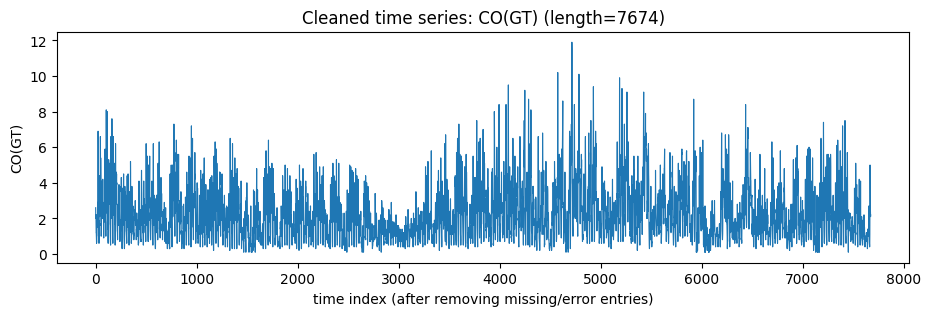

In [ ]:
x = x_raw.replace(-200, np.nan).dropna().astype(float)
dt_clean = dt.loc[x.index] if isinstance(dt, pd.Series) else pd.Series(np.arange(len(x)))

# reset indices for convenience
x = x.reset_index(drop=True)
dt_clean = dt_clean.reset_index(drop=True)

print("Cleaned length:", len(x))
print(x.describe())

plt.figure(figsize=(11, 3))
plt.plot(x.values, linewidth=0.8)
plt.title(f"Cleaned time series: {col} (length={len(x)})")
plt.xlabel("time index (after removing missing/error entries)")
plt.ylabel(col)
plt.show()


## 3. Discretize into a finite state space (Step 3)

You must map each observation to exactly one state in a **finite** state space:
$$
S=\{1,2,\dots,m\}.
$$

### Common discretization choices
- **Rounding** to nearest integer (works if values are already near small integers)
- **Equal-width bins** across the data range
- **Quantile bins** (each state has roughly equal empirical frequency)

### TODO
Choose:
- Number of states `m` (typical: 5–15)
- A discretization rule
- Justify in your report

This cell outputs:
- `states` as integers in `{0,1,...,m-1}` (0-indexed for coding convenience)
- `m` number of states
- `bin_edges` (if binning is used)

We map each observation to a state in \(\{0,1,\dots,m-1\}\) (0-indexed for code).

We use **quantile bins by default** to ensure each state has enough observations.


Discretization: quantile
m = 9
Used states: [0 1 2 3 4 5 6 7 8]


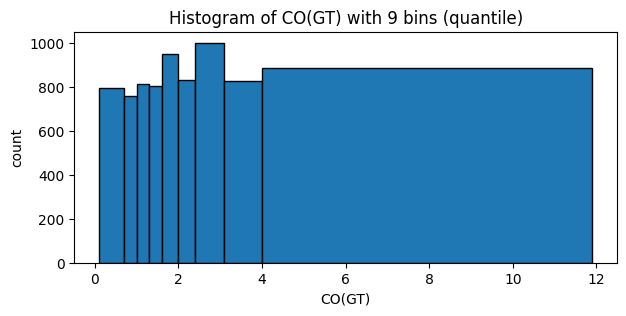

,x,state
0,2.6,6
1,2.0,5
2,2.2,5
3,2.2,5
4,1.6,4
5,1.2,2
6,1.2,2
7,1.0,2
8,0.9,1
9,0.6,0


In [ ]:
m = 9
DISCRETIZATION = "quantile"  # "quantile" or "equalwidth"

x_values = x.values

if DISCRETIZATION == "quantile":
    q = np.linspace(0, 1, m + 1)
    edges = np.quantile(x_values, q)
    edges = np.unique(edges)
    if len(edges) < m + 1:
        print("Warning: quantile edges collapsed (ties). Falling back to equal-width bins.")
        DISCRETIZATION = "equalwidth"

if DISCRETIZATION == "equalwidth":
    x_min, x_max = float(np.min(x_values)), float(np.max(x_values))
    edges = np.linspace(x_min, x_max, m + 1)

bin_edges = edges
states = np.digitize(x_values, bin_edges[1:-1], right=False)

print("Discretization:", DISCRETIZATION)
print("m =", m)
print("Used states:", np.unique(states))
assert states.min() >= 0 and states.max() <= m-1

plt.figure(figsize=(7, 3))
plt.hist(x_values, bins=bin_edges, edgecolor="black")
plt.title(f"Histogram of {col} with {m} bins ({DISCRETIZATION})")
plt.xlabel(col)
plt.ylabel("count")
plt.show()

pd.DataFrame({"x": x_values[:12], "state": states[:12]})


## 4. Empirical distribution  

Compute:
$$
\hat\pi_i=\frac{1}{n}\sum_{t=1}^n \mathbf{1}\{X_t=i\}.
$$

This estimates the fraction of time the chain spends in each state.


Empirical distribution (sum = 1.0 ):
state 0: 0.1039  (count=797)
state 1: 0.0989  (count=759)
state 2: 0.1061  (count=814)
state 3: 0.1049  (count=805)
state 4: 0.1238  (count=950)
state 5: 0.1084  (count=832)
state 6: 0.1306  (count=1002)
state 7: 0.1076  (count=826)
state 8: 0.1158  (count=889)


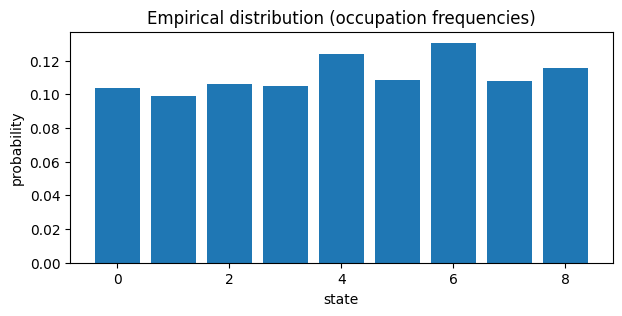

In [ ]:
n = len(states)
counts = np.bincount(states, minlength=m)
pi_hat = counts / n

print("Empirical distribution (sum =", pi_hat.sum(), "):")
for i, p in enumerate(pi_hat):
    print(f"state {i}: {p:.4f}  (count={counts[i]})")

plt.figure(figsize=(7, 3))
plt.bar(np.arange(m), pi_hat)
plt.title("Empirical distribution (occupation frequencies)")
plt.xlabel("state")
plt.ylabel("probability")
plt.show()


## 5. Transition matrix

Count one-step transitions:
$$
N_{ij}=\#\{t: X_t=i, X_{t+1}=j\},\qquad
\hat p_{ij}=\frac{N_{ij}}{\sum_j N_{ij}}.
$$

Rows of $\hat P$ should sum to 1 **for states that appear** with outgoing transitions.

<>:17: SyntaxWarning: invalid escape sequence '\h'
<>:17: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-4005615261.py:17: SyntaxWarning: invalid escape sequence '\h'
  plt.title("Estimated transition matrix $\hat P$")


Row sums (valid rows) min/max: 0.9999999999999999 1.0000000000000002


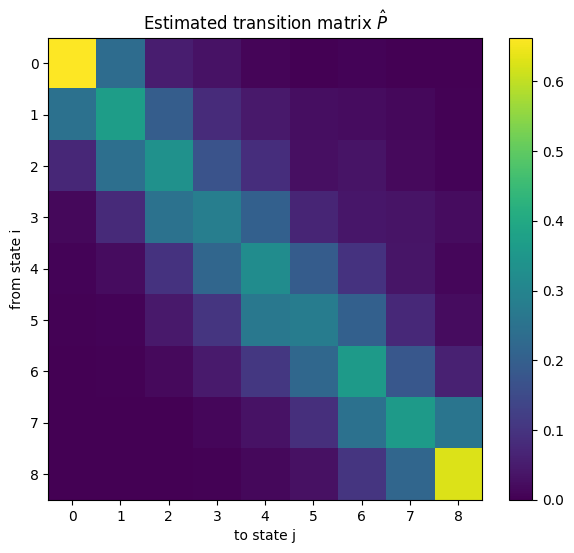

,0,1,2,3,4,5,6,7,8
0,0.662,0.235,0.054,0.031,0.009,0.001,0.006,0.000,0.001
1,0.246,0.369,0.195,0.080,0.045,0.024,0.022,0.014,0.004
2,0.075,0.243,0.335,0.171,0.087,0.028,0.036,0.017,0.007
3,0.015,0.078,0.250,0.284,0.204,0.070,0.041,0.036,0.022
4,0.005,0.023,0.097,0.218,0.322,0.192,0.096,0.037,0.011
5,0.004,0.006,0.045,0.101,0.265,0.278,0.203,0.077,0.022
6,0.001,0.003,0.017,0.048,0.108,0.221,0.360,0.181,0.062
7,0.000,0.001,0.002,0.011,0.033,0.088,0.247,0.361,0.257
8,0.000,0.000,0.001,0.003,0.015,0.030,0.103,0.218,0.629


In [ ]:
N_ij = np.zeros((m, m), dtype=int)
for t in range(n - 1):
    i, j = states[t], states[t + 1]
    N_ij[i, j] += 1

row_sums = N_ij.sum(axis=1, keepdims=True)
P_hat = np.divide(N_ij, row_sums, out=np.zeros_like(N_ij, dtype=float), where=row_sums > 0)

valid_rows = (row_sums[:, 0] > 0)
print("Row sums (valid rows) min/max:",
      float(P_hat[valid_rows].sum(axis=1).min()),
      float(P_hat[valid_rows].sum(axis=1).max()))

plt.figure(figsize=(7, 6))
plt.imshow(P_hat, aspect="auto")
plt.colorbar()
plt.title("Estimated transition matrix $\hat P$")
plt.xlabel("to state j")
plt.ylabel("from state i")
plt.show()

pd.DataFrame(P_hat).style.format("{:.3f}")


## 6. Stationary distribution

Solve:
$$
\pi = \pi \hat P,\quad \sum_i \pi_i=1.
$$

### Notes
- If the chain is **irreducible and aperiodic**, the stationary distribution is unique and is the long-run limit.
- If not irreducible, there may be multiple stationary distributions.

We compute a stationary vector via eigenvectors of $\hat P^\top$.

<>:13: SyntaxWarning: invalid escape sequence '\h'
<>:13: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-277852475.py:13: SyntaxWarning: invalid escape sequence '\h'
  plt.title("Stationary distribution of $\hat P$")


Stationary distribution (sum = 1.0000000000000002 ):
state 0: 0.1039
state 1: 0.0989
state 2: 0.1061
state 3: 0.1049
state 4: 0.1238
state 5: 0.1084
state 6: 0.1304
state 7: 0.1076
state 8: 0.1158


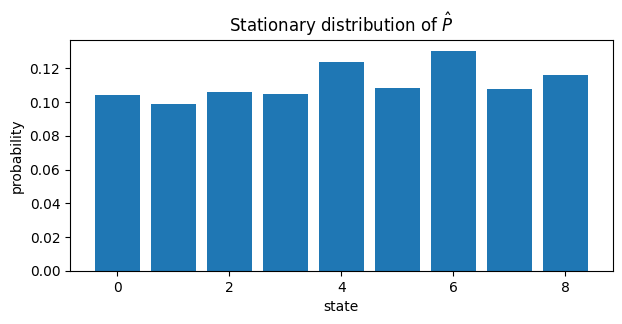

In [ ]:
eigvals, eigvecs = np.linalg.eig(P_hat.T)
k = np.argmin(np.abs(eigvals - 1.0))
pi = np.real(eigvecs[:, k])
pi = np.abs(pi)
pi = pi / pi.sum()

print("Stationary distribution (sum =", pi.sum(), "):")
for i, p in enumerate(pi):
    print(f"state {i}: {p:.4f}")

plt.figure(figsize=(7, 3))
plt.bar(np.arange(m), pi)
plt.title("Stationary distribution of $\hat P$")
plt.xlabel("state")
plt.ylabel("probability")
plt.show()


## 7. Compare empirical vs stationary distributions


Plot both on the same axes and comment in your report:
- Are they close?
- If not, why might they differ? (nonstationarity, discretization, insufficient mixing, reducibility, etc.)

<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:3: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-2378769647.py:2: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(pi_hat, marker="o", label="empirical $\hat\pi$")
/tmp/ipython-input-2378769647.py:3: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(pi, marker="s", label="stationary $\pi$")


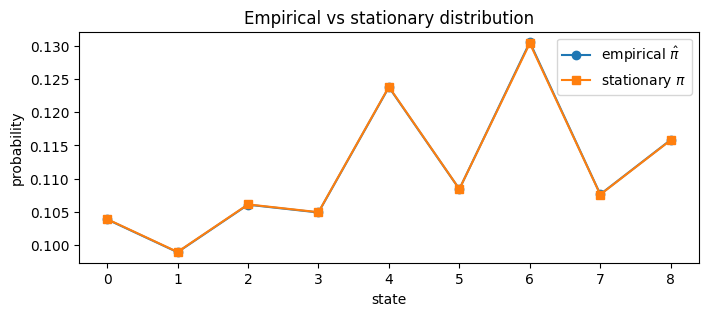

L1 distance: 0.0004626174801466154
L-infinity distance: 0.00016181372731133292


In [ ]:
plt.figure(figsize=(8, 3))
plt.plot(pi_hat, marker="o", label="empirical $\hat\pi$")
plt.plot(pi, marker="s", label="stationary $\pi$")
plt.title("Empirical vs stationary distribution")
plt.xlabel("state")
plt.ylabel("probability")
plt.legend()
plt.show()

print("L1 distance:", float(np.sum(np.abs(pi_hat - pi))))
print("L-infinity distance:", float(np.max(np.abs(pi_hat - pi))))


## 8. Simulate the fitted Markov chain

Simulate a chain using $\hat P$ and compare a typical simulated time series with the original.

### TODO
- Choose an initial state (e.g., first observed state)
- Simulate for the same length as the original
- Compare visually

<>:40: SyntaxWarning: invalid escape sequence '\h'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:40: SyntaxWarning: invalid escape sequence '\h'
<>:41: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-247844389.py:40: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(pi_hat, marker="o", label="empirical $\hat\pi$")
/tmp/ipython-input-247844389.py:41: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(pi, marker="s", label="stationary $\pi$")


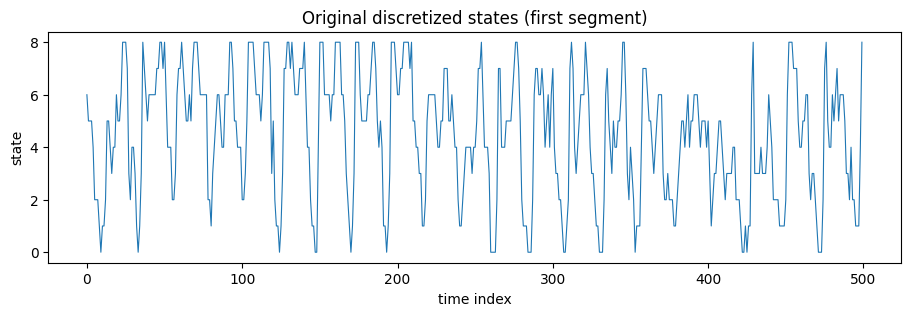

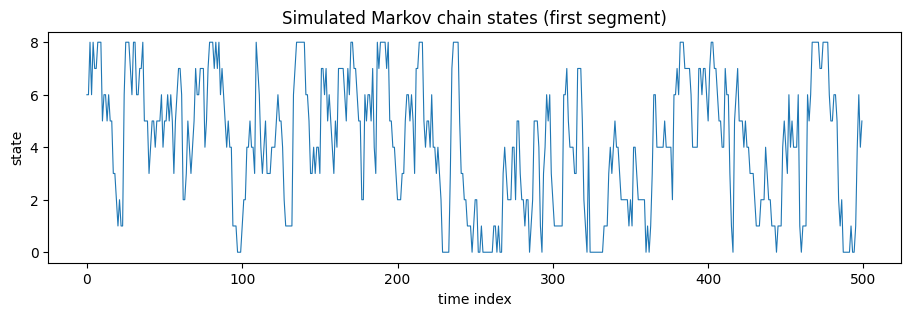

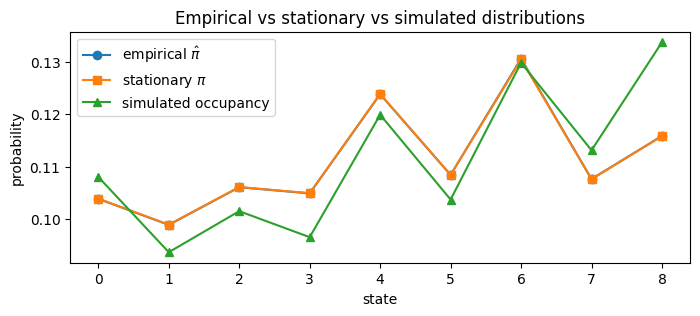

In [ ]:
def simulate_markov_chain(P, x0, T, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    m = P.shape[0]
    X = np.empty(T, dtype=int)
    X[0] = x0
    for t in range(1, T):
        i = X[t-1]
        probs = P[i]
        if probs.sum() == 0:
            X[t] = i
        else:
            X[t] = rng.choice(m, p=probs)
    return X

rng = np.random.default_rng(1)
T = len(states)
Xsim = simulate_markov_chain(P_hat, x0=int(states[0]), T=T, rng=rng)

L = min(500, T)

plt.figure(figsize=(11, 3))
plt.plot(states[:L], linewidth=0.8)
plt.title("Original discretized states (first segment)")
plt.xlabel("time index")
plt.ylabel("state")
plt.show()

plt.figure(figsize=(11, 3))
plt.plot(Xsim[:L], linewidth=0.8)
plt.title("Simulated Markov chain states (first segment)")
plt.xlabel("time index")
plt.ylabel("state")
plt.show()

counts_sim = np.bincount(Xsim, minlength=m)
pi_sim = counts_sim / T

plt.figure(figsize=(8, 3))
plt.plot(pi_hat, marker="o", label="empirical $\hat\pi$")
plt.plot(pi, marker="s", label="stationary $\pi$")
plt.plot(pi_sim, marker="^", label="simulated occupancy")
plt.title("Empirical vs stationary vs simulated distributions")
plt.xlabel("state")
plt.ylabel("probability")
plt.legend()
plt.show()


## 9. Goodness-of-fit test for 2-step transitions  

We compare observed 2-step transitions from the original discretized series to the expected 2-step transitions under the fitted 1-step Markov model.

### Observed (2-step) counts
$$
N^{(2)}_{ij}=\#\{t: X_t=i,\;X_{t+2}=j\}.
$$
Let $N_i=\sum_j N^{(2)}_{ij}$.

### Expected counts
Let $\hat P^{(2)}=\hat P^2$. Then
$$
M_{ij}=N_i (\hat P^{(2)})_{ij}.
$$

### Chi-square statistic (for each fixed i or overall pooled)
$$
\\chi^2 = \sum_{i,j} \frac{(N^{(2)}_{ij}-M_{ij})^2}{M_{ij}}.
$$

**Important pooling rule:** If some $M_{ij}<4$, you should pool categories (for fixed i) so each expected count is ≥ 4.

This notebook provides:
- Overall chi-square (unpooled) as a starting point
- A per-row diagnostic of small expected counts

**TODO:** Implement pooling for your data and write up the decision at 5% significance.


We implement:
1) unpooled diagnostic chi-square  
2) pooled chi-square using a simple row-wise pooling strategy so all expected counts are ≥ 4.


In [ ]:
# Observed 2-step counts
N2 = np.zeros((m, m), dtype=int)
for t in range(n - 2):
    i, j = states[t], states[t + 2]
    N2[i, j] += 1

Ni = N2.sum(axis=1)
P2 = P_hat @ P_hat
M = Ni[:, None] * P2

# Unpooled diagnostic
mask = (M > 0)
chi2_unpooled = float(np.sum((N2[mask] - M[mask])**2 / M[mask]))
num_cells = int(mask.sum())
num_rows = int((Ni > 0).sum())
df_baseline = max(num_cells - num_rows, 1)

print("Unpooled chi-square (diagnostic):", chi2_unpooled)
print("Baseline df (approx):", df_baseline)
if SCIPY_AVAILABLE:
    print("Unpooled p-value (diagnostic):", float(1 - chi2.cdf(chi2_unpooled, df_baseline)))

print("Cells with 0 < expected < 4:", int(((M > 0) & (M < 4)).sum()))


Unpooled chi-square (diagnostic): 484.18399532836395
Baseline df (approx): 72
Unpooled p-value (diagnostic): 0.0
Cells with 0 < expected < 4: 5


In [ ]:
def pool_categories_per_row(observed_row, expected_row, min_expected=4.0):
    """Pool categories for a single row by merging adjacent bins until all expected >= min_expected.

    Transparent rule:
    - Remove categories with expected=0
    - While some expected < min_expected and >1 category remains:
        merge the smallest-expected category with a neighbor (prefer right, else left)
    """
    obs = observed_row.astype(float).copy()
    exp = expected_row.astype(float).copy()
    groups = [[j] for j in range(len(obs))]

    keep = exp > 0
    obs = obs[keep]
    exp = exp[keep]
    groups = [g for g, k in zip(groups, keep) if k]

    if len(exp) == 0:
        return np.array([]), np.array([]), []

    while (exp < min_expected).any() and len(exp) > 1:
        idx = int(np.argmin(exp))
        if idx < len(exp) - 1:
            j_merge = idx + 1
        else:
            j_merge = idx - 1

        new_obs = obs[j_merge] + obs[idx]
        new_exp = exp[j_merge] + exp[idx]
        new_group = groups[j_merge] + groups[idx]

        lo = min(idx, j_merge)
        hi = max(idx, j_merge)

        obs = np.delete(obs, [lo, hi])
        exp = np.delete(exp, [lo, hi])
        groups = [g for k, g in enumerate(groups) if k not in (lo, hi)]

        obs = np.insert(obs, lo, new_obs)
        exp = np.insert(exp, lo, new_exp)
        groups.insert(lo, new_group)

    return obs, exp, groups


chi2_pooled = 0.0
df_pooled = 0
pooling_details = {}

for i in range(m):
    if Ni[i] == 0:
        continue
    obs_row = N2[i, :]
    exp_row = M[i, :]
    obs_p, exp_p, groups = pool_categories_per_row(obs_row, exp_row, min_expected=4.0)

    if len(exp_p) == 0:
        continue

    chi2_i = float(np.sum((obs_p - exp_p)**2 / exp_p))
    chi2_pooled += chi2_i

    df_i = max(len(exp_p) - 1, 0)
    df_pooled += df_i

    pooling_details[i] = (groups, df_i, chi2_i)

print("Pooled chi-square:", float(chi2_pooled))
print("Pooled df:", int(df_pooled))

if SCIPY_AVAILABLE and df_pooled > 0:
    p_pooled = float(1 - chi2.cdf(chi2_pooled, df_pooled))
    crit = float(chi2.ppf(0.95, df_pooled))
    print("Pooled p-value:", p_pooled)
    print("Critical value (alpha=0.05):", crit)

for i in sorted(pooling_details.keys())[:3]:
    groups, df_i, chi2_i = pooling_details[i]
    print(f"Row i={i}: pooled groups={groups} | df={df_i} | chi2={chi2_i:.2f}")


Pooled chi-square: 480.02768285295946
Pooled df: 68
Pooled p-value: 0.0
Critical value (alpha=0.05): 88.25016442187412
Row i=0: pooled groups=[[0], [1], [2], [3], [4], [5], [6], [7, 8]] | df=7 | chi2=180.97
Row i=1: pooled groups=[[0], [1], [2], [3], [4], [5], [6], [7], [8]] | df=8 | chi2=143.59
Row i=2: pooled groups=[[0], [1], [2], [3], [4], [5], [6], [7], [8]] | df=8 | chi2=22.93


### 9.1 Heatmaps (optional appendix figures)

<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-1380707581.py:12: SyntaxWarning: invalid escape sequence '\h'
  plt.title("Expected 2-step counts $M_{ij}$ under $\hat P^2$")


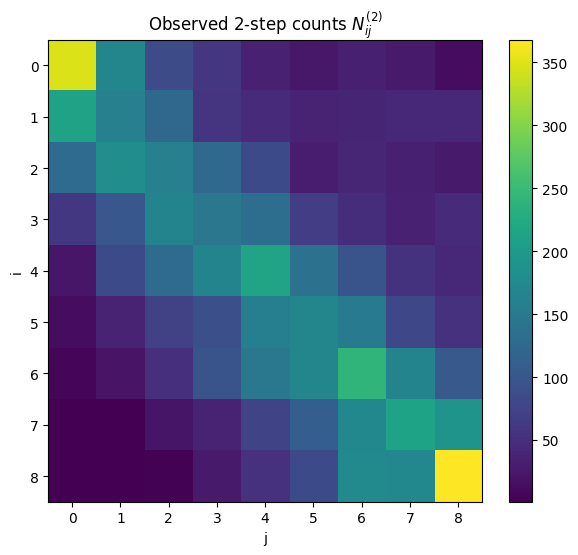

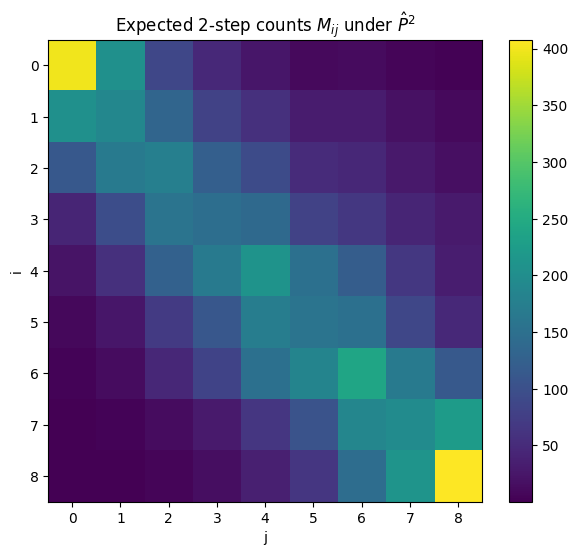

In [ ]:
plt.figure(figsize=(7, 6))
plt.imshow(N2, aspect="auto")
plt.colorbar()
plt.title("Observed 2-step counts $N^{(2)}_{ij}$")
plt.xlabel("j")
plt.ylabel("i")
plt.show()

plt.figure(figsize=(7, 6))
plt.imshow(M, aspect="auto")
plt.colorbar()
plt.title("Expected 2-step counts $M_{ij}$ under $\hat P^2$")
plt.xlabel("j")
plt.ylabel("i")
plt.show()


## 10. Final summary  

In [ ]:
summary = {
    "column": col,
    "n_clean": int(len(x)),
    "discretization": DISCRETIZATION,
    "m_states": int(m),
    "L1(empirical,stationary)": float(np.sum(np.abs(pi_hat - pi))),
    "chi2_unpooled": float(chi2_unpooled),
    "df_unpooled_approx": int(df_baseline),
    "chi2_pooled": float(chi2_pooled),
    "df_pooled": int(df_pooled),
}
if SCIPY_AVAILABLE and df_pooled > 0:
    summary["p_value_pooled"] = float(1 - chi2.cdf(chi2_pooled, df_pooled))
summary


{'column': 'CO(GT)',
 'n_clean': 7674,
 'discretization': 'quantile',
 'm_states': 9,
 'L1(empirical,stationary)': 0.0004626174801466154,
 'chi2_unpooled': 484.18399532836395,
 'df_unpooled_approx': 72,
 'chi2_pooled': 480.02768285295946,
 'df_pooled': 68,
 'p_value_pooled': 0.0}